# ⚡ GOLD BOT V2 — Backtester Multi-Dataset XAUUSD
### Safe / Risque / Risque+++ | Spread & Slippage réalistes
---
**Datasets :** 6 Mois · 1 An · 2 Ans · 3 Ans  
**Modifie uniquement la cellule CONFIG** ci-dessous, puis `Run All`.


## 📦 Installation (dans ton venv, une seule fois)
```bash
pip install pandas numpy matplotlib openpyxl jupyterlab
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, re
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')


Imports OK


## ⚙️ CONFIGURATION — Tout modifier ici
> Seule cellule à toucher. Relance ensuite `Kernel > Restart & Run All`.


In [2]:
# ═══════════════════════════════════════════════════════
# 📂  FICHIERS CSV
# ═══════════════════════════════════════════════════════
DATASETS = {
    "6 Mois" : "XAUUSD-VIP_M5_6Months_Data.csv",
    "1 An"   : "XAUUSD-VIP_M5_1Year_Data.csv",
    "2 Ans"  : "XAUUSD-VIP_M5_2Years_Data.csv",
    "3 Ans"  : "XAUUSD-VIP_M5_3Years_Data.csv",
}
# Mets False pour ignorer un dataset
DATASET_ENABLED = {k: True for k in DATASETS}

# ═══════════════════════════════════════════════════════
# 💸  COUTS TRANSACTIONNELS
# ═══════════════════════════════════════════════════════
SPREAD   = 0.0   # pts — spread broker  (ECN gold: 0.20-0.50)
SLIPPAGE = 0.0   # pts — glissement/leg (news: jusqu a 0.50)

# ═══════════════════════════════════════════════════════
# 📊  TAILLE DE POSITION
# ═══════════════════════════════════════════════════════
LOT_SIZE    = 0.01    # lots — 0.01 = micro-lot
POINT_VALUE = 100.0   # $/lot/pt  (XAUUSD : 1 lot = 100 oz)

# ═══════════════════════════════════════════════════════
# 🛡️  RISK MANAGEMENT
# ═══════════════════════════════════════════════════════
MAX_RISK_PTS       = 22.0   # risque max/trade (pts)
DAILY_MAX_LOSS     = -150.0 # coupe-circuit jour ($)
MAX_TRADES_PER_DAY = 3      # sequences max/jour

# ═══════════════════════════════════════════════════════
# 🕐  SESSION UTC
# ═══════════════════════════════════════════════════════
SESSION_START_H = 5
SESSION_END_H   = 15
SESSION_MID_H   = 12  # apres cette heure : threshold +10

# ═══════════════════════════════════════════════════════
# ⚡  MODES  (sl/tp multipliers, score_min, cooldown)
# ═══════════════════════════════════════════════════════
MODES_CONFIG = {
    "safe": {
        "sl_mult":2.5,"tp1_mult":1.5,"tp2_mult":2.5,"tp3_mult":4.0,
        "score_min":60,"cooldown_bars":60,
        "label":"SAFE","color":"#2ecc71","desc":"SL large, setups premium",
    },
    "risque": {
        "sl_mult":1.8,"tp1_mult":1.2,"tp2_mult":2.0,"tp3_mult":3.2,
        "score_min":45,"cooldown_bars":36,
        "label":"RISQUE","color":"#f39c12","desc":"Equilibre standard",
    },
    "risque+++": {
        "sl_mult":1.5,"tp1_mult":1.0,"tp2_mult":1.8,"tp3_mult":2.8,
        "score_min":35,"cooldown_bars":18,
        "label":"RISQUE+++","color":"#e74c3c","desc":"SL minimum, haute freq",
    },
}
MODES = ['safe','risque','risque+++']

# ═══════════════════════════════════════════════════════
# 🔧  MOTEUR INTERNE
# ═══════════════════════════════════════════════════════
LOOKBACK      = 200
MAX_HOLD_BARS = 200
VERBOSE       = False  # True = affiche chaque trade

print(f'Config OK — Spread={SPREAD}pt | Slippage={SLIPPAGE}pt | Lot={LOT_SIZE}')
print(f'Session {SESSION_START_H}h-{SESSION_END_H}h UTC | Max {MAX_TRADES_PER_DAY} trades/jour')
print(f'Datasets actifs: {[k for k,v in DATASET_ENABLED.items() if v]}')


Config OK — Spread=0.0pt | Slippage=0.0pt | Lot=0.01
Session 5h-15h UTC | Max 3 trades/jour
Datasets actifs: ['6 Mois', '1 An', '2 Ans', '3 Ans']


## 🔧 Moteur — Indicateurs & Simulation


In [3]:
# ── INDICATEURS VECTORISÉS ──────────────────────────────────────────────
def compute_all_indicators_vectorized(df):
    df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['TP_Vol'] = df['Typical_Price'] * df['Volume']
    df['Cum_Vol_50'] = df['Volume'].rolling(50).sum()
    df['VWAP'] = df['TP_Vol'].rolling(50).sum() / df['Cum_Vol_50']
    df['VWAP'] = df['VWAP'].fillna(df['Typical_Price'])
    
    tr1 = df['High'] - df['Low']
    tr2 = (df['High'] - df['Close'].shift()).abs()
    tr3 = (df['Low'] - df['Close'].shift()).abs()
    df['TR'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['ATR'] = df['TR'].rolling(14).mean().fillna(1.0)
    
    df['VWAP_STD'] = (df['Typical_Price'] - df['VWAP']).rolling(50).std()
    df['VWAP_STD'] = df['VWAP_STD'].fillna(df['ATR'])
    df.loc[df['VWAP_STD'] == 0, 'VWAP_STD'] = df.loc[df['VWAP_STD'] == 0, 'ATR']
    
    df['VWAP_U1'] = df['VWAP'] + 1.0 * df['VWAP_STD']
    df['VWAP_L1'] = df['VWAP'] - 1.0 * df['VWAP_STD']
    df['VWAP_U2'] = df['VWAP'] + 2.0 * df['VWAP_STD']
    df['VWAP_L2'] = df['VWAP'] - 2.0 * df['VWAP_STD']
    df['Dist_VWAP_SD'] = (df['Close'] - df['VWAP']) / df['VWAP_STD']
    df['VWAP_Slope'] = df['VWAP'].diff(5).fillna(0)
    
    df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()
    df['EMA50'] = df['Close'].ewm(span=50, adjust=False).mean()
    df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()
    
    df['EMA_Cross_Bull'] = (df['EMA20'] > df['EMA50']) & (df['EMA20'].shift(1) <= df['EMA50'].shift(1))
    df['EMA_Cross_Bear'] = (df['EMA20'] < df['EMA50']) & (df['EMA20'].shift(1) >= df['EMA50'].shift(1))
    
    df['Avg_Vol_20'] = df['Volume'].rolling(20).mean()
    df['Vol_Ratio'] = (df['Volume'] / df['Avg_Vol_20']).fillna(1.0)
    
    df['Swing_High'] = df['High'].rolling(30).max()
    df['Swing_Low'] = df['Low'].rolling(30).min()
    df['Move10'] = df['Close'].shift(1) - df['Close'].shift(10)
    df['Move10'] = df['Move10'].fillna(0)
    
    df['Body'] = (df['Close'] - df['Open']).abs()
    df['Cur_Bull'] = df['Close'] > df['Open']
    df['Cur_Bear'] = df['Close'] < df['Open']
    return df

def compute_volume_profile(df, bins=20):
    pmin, pmax = df['Low'].min(), df['High'].max()
    if pmax == pmin: 
        return {'poc': df['Close'].iloc[-1], 'value_area_high': pmax, 'value_area_low': pmin}
    vols, edges = np.histogram(df['Close'], bins=bins, weights=df['Volume'])
    pi = vols.argmax(); poc = (edges[pi] + edges[pi+1]) / 2
    acc, vai = 0, []
    for i in np.argsort(vols)[::-1]:
        acc += vols[i]; vai.append(i)
        if acc >= vols.sum() * 0.70: break
    return {'poc': round(poc, 2),
            'value_area_high': round(max((edges[i] + edges[i+1]) / 2 for i in vai), 2),
            'value_area_low' : round(min((edges[i] + edges[i+1]) / 2 for i in vai), 2)}

def _candle_pattern(df):
    o, h, l, c = df['Open'].iloc[-1], df['High'].iloc[-1], df['Low'].iloc[-1], df['Close'].iloc[-1]
    body, span = abs(c - o), h - l
    if span == 0: return 'Doji'
    r = body / span
    lw, uw = min(o, c) - l, h - max(o, c)
    if r < 0.1: return 'Doji'
    if lw > body * 2 and uw < body * 0.5 and c > o: return 'Marteau'
    if uw > body * 2 and lw < body * 0.5 and c < o: return 'Shooting Star'
    if len(df) < 2: return 'Neutre'
    po, pc = df['Open'].iloc[-2], df['Close'].iloc[-2]
    if c > o and c > po and o < pc and pc < po: return 'Engulfing haussier'
    if c < o and c < po and o > pc and pc > po: return 'Engulfing baissier'
    if lw > body * 3: return 'Pin Bar haussier'
    if uw > body * 3: return 'Pin Bar baissier'
    return 'Neutre'

def compute_score(ind, direction):
    sc, rs = 0, []
    ib = direction == 'BUY'
    dsd = abs(ind['dist_vwap_sd'])
    if dsd >= 2.0: sc += 30; rs.append(f'VWAP {dsd:.1f}SD')
    elif dsd >= 1.0: sc += 18
    elif dsd >= 0.5: sc += 8
    
    if ib and ind['vwap_slope'] > 0: sc += 5
    elif not ib and ind['vwap_slope'] < 0: sc += 5
    
    if ib:
        if ind['near_swing_sup']: sc += 15; rs.append(f'Sup@{ind["swing_low"]}')
        if ind['near_poc']: sc += 10; rs.append(f'POC@{ind["poc"]}')
        if ind['price'] < ind['va_low']: sc += 10
        if ind['above_200']: sc += 5
    else:
        if ind['near_swing_res']: sc += 15; rs.append(f'Res@{ind["swing_high"]}')
        if ind['near_poc']: sc += 10
        if ind['price'] > ind['va_high']: sc += 10
        if not ind['above_200']: sc += 5
        
    vr = ind['vol_ratio']
    if ind['bounce_bull'] or ind['bounce_bear']: sc += 25; rs.append(f'Bounce x{vr}')
    elif vr >= 2.0: sc += 20
    elif vr >= 1.4: sc += 12
    elif vr >= 1.0: sc += 5
    
    if ib and ind['ema_cross_bull']: sc += 10; rs.append('GoldenX')
    elif not ib and ind['ema_cross_bear']: sc += 10; rs.append('DeathX')
    
    bp = {'Marteau', 'Engulfing haussier', 'Pin Bar haussier'}
    brp = {'Shooting Star', 'Engulfing baissier', 'Pin Bar baissier'}
    if ib and ind['pattern'] in bp: sc += 15; rs.append(ind['pattern'])
    elif not ib and ind['pattern'] in brp: sc += 15; rs.append(ind['pattern'])
    elif ind['pattern'] == 'Doji': sc += 3
    
    return min(sc, 100), rs

def calculate_tp_sl(direction, entry, atr, sh, sl, mode):
    m = MODES_CONFIG[mode]
    if direction == 'BUY':
        s = min(round(sl - atr * 0.2, 2), round(entry - atr * m['sl_mult'], 2), round(entry - atr * max(m['sl_mult'], 1.5), 2))
        r = abs(entry - s)
        if r > MAX_RISK_PTS: s = round(entry - MAX_RISK_PTS, 2); r = MAX_RISK_PTS
        return {'sl': s, 'tp1': round(entry + r * m['tp1_mult'], 2), 'tp2': round(entry + r * m['tp2_mult'], 2),
                'tp3': round(entry + r * m['tp3_mult'], 2), 'risk': r}
    else:
        s = max(round(sh + atr * 0.2, 2), round(entry + atr * m['sl_mult'], 2), round(entry + atr * max(m['sl_mult'], 1.5), 2))
        r = abs(s - entry)
        if r > MAX_RISK_PTS: s = round(entry + MAX_RISK_PTS, 2); r = MAX_RISK_PTS
        return {'sl': s, 'tp1': round(entry - r * m['tp1_mult'], 2), 'tp2': round(entry - r * m['tp2_mult'], 2),
                'tp3': round(entry - r * m['tp3_mult'], 2), 'risk': r}

# ── COUTS TRANSACTIONNELS ───────────────────────────────────────────────
def _entry_cost(direction, raw):
    return round(raw + SPREAD + SLIPPAGE, 2) if direction == 'BUY' else round(raw - SLIPPAGE, 2)

def _exit_cost(direction, raw):
    return round(raw - SLIPPAGE, 2) if direction == 'BUY' else round(raw + SPREAD + SLIPPAGE, 2)

def calc_pnl(direction, entry, exit_price):
    return round((exit_price - entry) * (1.0 if direction == 'BUY' else -1.0) * LOT_SIZE * POINT_VALUE, 2)

# ── SIMULATION ──────────────────────────────────────────────────────────
def sim_subtrade(direction, entry, sl, tp, fut):
    csl = sl
    for idx, row in fut.iterrows():
        bo, bh, bl = row['Open'], row['High'], row['Low']
        if direction == 'BUY':
            if bo <= csl: return {'result': 'SL', 'exit_idx': idx, 'pnl': calc_pnl(direction, entry, _exit_cost(direction, csl))}
            if bo >= tp:  return {'result': 'TP', 'exit_idx': idx, 'pnl': calc_pnl(direction, entry, _exit_cost(direction, tp))}
            if bl <= csl: return {'result': 'SL', 'exit_idx': idx, 'pnl': calc_pnl(direction, entry, _exit_cost(direction, csl))}
            if bh >= tp:  return {'result': 'TP', 'exit_idx': idx, 'pnl': calc_pnl(direction, entry, _exit_cost(direction, tp))}
        else:
            if bo >= csl: return {'result': 'SL', 'exit_idx': idx, 'pnl': calc_pnl(direction, entry, _exit_cost(direction, csl))}
            if bo <= tp:  return {'result': 'TP', 'exit_idx': idx, 'pnl': calc_pnl(direction, entry, _exit_cost(direction, tp))}
            if bh >= csl: return {'result': 'SL', 'exit_idx': idx, 'pnl': calc_pnl(direction, entry, _exit_cost(direction, csl))}
            if bl <= tp:  return {'result': 'TP', 'exit_idx': idx, 'pnl': calc_pnl(direction, entry, _exit_cost(direction, tp))}
            
    lc = fut['Close'].iloc[-1]
    return {'result': 'TIMEOUT', 'exit_idx': fut.index[-1], 'pnl': calc_pnl(direction, entry, _exit_cost(direction, lc))}

def sim_sequence(direction, entry, levels, fut):
    sl = levels['sl']; tps = [levels['tp1'], levels['tp2'], levels['tp3']]
    r1 = sim_subtrade(direction, entry, sl, tps[0], fut)
    sl2 = entry if r1['result'] == 'TP' else sl
    r2 = sim_subtrade(direction, entry, sl2, tps[1], fut)
    sl3 = tps[0] if r2['result'] == 'TP' else sl2
    r3 = sim_subtrade(direction, entry, sl3, tps[2], fut)
    return [r1, r2, r3]

print('Moteur vectoriel charge OK')

Moteur vectoriel charge OK


In [4]:
def run_backtest(df, mode):
    m = MODES_CONFIG[mode]; trades = []; equity = [0.0]
    dpnl, ntd = 0.0, 0; lsig, lsl = -9999, -9999
    dph = {}; cur_date = None; dstop = False
    
    # Prechargement des valeurs dans des tableaux Numpy pour la vitesse absolue
    closes = df['Close'].values
    atrs = df['ATR'].values
    vwap_u1 = df['VWAP_U1'].values
    vwap_l1 = df['VWAP_L1'].values
    vwap_u2 = df['VWAP_U2'].values
    vwap_l2 = df['VWAP_L2'].values
    dist_sd = df['Dist_VWAP_SD'].values
    vwap_slope = df['VWAP_Slope'].values
    
    ema200 = df['EMA200'].values
    ema50 = df['EMA50'].values
    ema_xbull = df['EMA_Cross_Bull'].values
    ema_xbear = df['EMA_Cross_Bear'].values
    
    vol_ratio = df['Vol_Ratio'].values
    swing_highs = df['Swing_High'].values
    swing_lows = df['Swing_Low'].values
    move10 = df['Move10'].values
    
    bodies = df['Body'].values
    cur_bull = df['Cur_Bull'].values
    cur_bear = df['Cur_Bear'].values
    
    if 'time' in df.columns:
        times = df['time'].dt.to_pydatetime()
        hours = df['time'].dt.hour.values
        dates = df['time'].dt.date.values
    else:
        hours = np.array([(bi % 24) for bi in range(len(df))])
        dates = np.array([None] * len(df))
        times = np.array([None] * len(df))

    n = len(df); bi = LOOKBACK

    while bi < n - MAX_HOLD_BARS:
        bd = dates[bi]
        if bd and bd != cur_date:
            if cur_date is not None: dph[cur_date] = dpnl
            cur_date = bd; dpnl = 0.0; ntd = 0; dstop = False
            
        if dstop: bi += 1; continue
        if dpnl < DAILY_MAX_LOSS: dstop = True; bi += 1; continue
        if ntd >= MAX_TRADES_PER_DAY: bi += 1; continue
        
        h = hours[bi]
        if h >= SESSION_END_H or h < SESSION_START_H: bi += 1; continue
        if bi - lsig < m['cooldown_bars']: bi += 1; continue

        vslope = vwap_slope[bi]
        atr = atrs[bi]
        if abs(vslope) < atr * 0.1: bi += 1; continue
        dsd = dist_sd[bi]
        if abs(dsd) > 4.5: bi += 1; continue
        
        price = closes[bi]
        sh = swing_highs[bi]
        sl = swing_lows[bi]
        nsup = abs(price - sl) < atr * 1.0
        nres = abs(price - sh) < atr * 1.0
        ab200 = price > ema200[bi]
        ab50 = price > ema50[bi]
        vr = vol_ratio[bi]
        
        # Filtres rapides avant le calcul lourd (Early Exit)
        bb_pre = (nsup and cur_bull[bi] and bodies[bi] > atr * 0.5 and vr > 1.4 and move10[bi] < -atr * 1.5)
        bs_pre = (nres and cur_bear[bi] and bodies[bi] > atr * 0.5 and vr > 1.4 and move10[bi] > atr * 1.5)
        vo = vr > 1.0
        
        # Isolation operation couteuse Volume Profile
        vp = compute_volume_profile(df.iloc[bi-100:bi])
        poc = vp['poc']
        npoc = abs(price - poc) < atr * 0.5
        
        bb = bb_pre and (not ab200 or (ab200 and npoc))
        bs = bs_pre
        
        direction = None
        if bb: direction = 'BUY'
        elif bs: direction = 'SELL'
        elif (price < vwap_l1[bi] and (nsup or npoc) and ab200 and ab50 and (vo or ema_xbull[bi])): direction = 'BUY'
        elif (price > vwap_u1[bi] and (nres or npoc) and not ab200 and not ab50 and (vo or ema_xbear[bi])): direction = 'SELL'
        elif price < vwap_l2[bi] and ab200 and vo: direction = 'BUY'
        elif price > vwap_u2[bi] and not ab200 and vo: direction = 'SELL'
        
        if direction is None: bi += 1; continue
        
        ind = {
            'price': price, 'atr': atr, 'vwap_slope': vslope, 'dist_vwap_sd': dsd,
            'near_swing_sup': nsup, 'near_swing_res': nres, 'swing_high': sh, 'swing_low': sl,
            'near_poc': npoc, 'poc': poc, 'va_low': vp['value_area_low'], 'va_high': vp['value_area_high'],
            'above_200': ab200, 'vol_ratio': vr, 'bounce_bull': bb, 'bounce_bear': bs,
            'ema_cross_bull': ema_xbull[bi], 'ema_cross_bear': ema_xbear[bi],
            'pattern': _candle_pattern(df.iloc[bi-2:bi+1])
        }
        
        sc, rs = compute_score(ind, direction)
        thr = m['score_min']
        if h >= SESSION_MID_H: thr += 10
        if bi - lsl < 60: thr += 20
        if sc < thr: bi += 1; continue
        
        raw_e = round(price, 2)
        entry = _entry_cost(direction, raw_e)
        lvl = calculate_tp_sl(direction, raw_e, atr, sh, sl, mode)
        
        fut = df.iloc[bi+1:bi+1+MAX_HOLD_BARS].reset_index(drop=True)
        if len(fut) < 5: bi += 1; continue
        
        sub = sim_sequence(direction, entry, lvl, fut)
        tp = sum(r['pnl'] for r in sub)
        outs = [r['result'] for r in sub]
        mei = max(r['exit_idx'] for r in sub)
        tph = outs.count('TP'); slh = outs.count('SL')
        res = 'TP' if tph >= 2 else ('SL' if slh >= 2 else 'MIXED')
        txc = round((SPREAD + 2 * SLIPPAGE) * 3 * LOT_SIZE * POINT_VALUE, 2)
        
        bt = times[bi] if times[bi] is not None else pd.Timestamp(f'2024-01-01 {bi%24:02d}:00')
        
        trades.append({'bar_idx': bi, 'time': bt, 'direction': direction,
                       'entry_raw': raw_e, 'entry_adj': entry,
                       'sl': lvl['sl'], 'tp1': lvl['tp1'], 'tp2': lvl['tp2'], 'tp3': lvl['tp3'],
                       'risk_pts': lvl['risk'], 'score': sc, 'threshold': thr,
                       'reasons': ', '.join(rs), 'atr': atr, 'transaction_cost': txc,
                       't1_result': outs[0], 't1_pnl': sub[0]['pnl'],
                       't2_result': outs[1], 't2_pnl': sub[1]['pnl'],
                       't3_result': outs[2], 't3_pnl': sub[2]['pnl'],
                       'total_pnl': round(tp, 2), 'result': res})
                       
        dpnl += tp; ntd += 1
        equity.append(round(equity[-1] + tp, 2))
        lsig = bi
        if slh >= 2: lsl = bi
        
        if VERBOSE: print(f'  [{bt}] {direction} sc={sc}/{thr} pnl={tp:+.2f}$ {outs}')
        bi += mei + 2

    if cur_date and dpnl: dph[cur_date] = dpnl
    df_t = pd.DataFrame(trades) if trades else pd.DataFrame()
    st = _stats(df_t, equity, dph)
    st.update({'mode': mode, 'trades_df': df_t, 'equity': equity, 'daily_pnl': dph})
    return st

def _stats(df_t, equity, dph):
    z = {'n_sequences':0, 'winrate':0, 'total_pnl':0, 'avg_pnl':0, 'best':0, 'worst':0,
         'max_dd':0, 'sharpe':0, 'profit_factor':0, 'avg_risk':0, 'avg_score':0,
         'n_tp':0, 'n_sl':0, 'n_mixed':0, 'n_buy':0, 'n_sell':0, 'total_transaction_costs':0}
    if df_t.empty: return z
    
    n = len(df_t)
    gp = df_t[df_t['total_pnl'] > 0]['total_pnl'].sum()
    gl = abs(df_t[df_t['total_pnl'] < 0]['total_pnl'].sum())
    pf = round(gp/gl, 2) if gl > 0 else float('inf')
    
    ea = np.array(equity); pk = np.maximum.accumulate(ea)
    mdd = round((ea - pk).min(), 2)
    
    dv = np.array(list(dph.values()))
    sharpe = round(dv.mean()/dv.std() * np.sqrt(252), 2) if len(dv) > 1 and dv.std() > 0 else 0
    txc = round(df_t['transaction_cost'].sum(), 2) if 'transaction_cost' in df_t.columns else 0
    
    return {'n_sequences': n, 'winrate': round((df_t['total_pnl'] > 0).sum() / n * 100, 1),
            'total_pnl': round(df_t['total_pnl'].sum(), 2), 'avg_pnl': round(df_t['total_pnl'].mean(), 2),
            'best': round(df_t['total_pnl'].max(), 2), 'worst': round(df_t['total_pnl'].min(), 2),
            'max_dd': mdd, 'sharpe': sharpe, 'profit_factor': pf,
            'avg_risk': round(df_t['risk_pts'].mean(), 2), 'avg_score': round(df_t['score'].mean(), 1),
            'n_tp': (df_t['result'] == 'TP').sum(), 'n_sl': (df_t['result'] == 'SL').sum(),
            'n_mixed': (df_t['result'] == 'MIXED').sum(),
            'n_buy': (df_t['direction'] == 'BUY').sum(), 'n_sell': (df_t['direction'] == 'SELL').sum(),
            'total_transaction_costs': txc}

print('Boucle vectorisee prete')

Boucle vectorisee prete


## 📂 Chargement des CSV


In [5]:
def load_csv(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    rn = {}
    for c in df.columns:
        cl = c.lower()
        if cl == 'open': rn[c] = 'Open'
        if cl == 'high': rn[c] = 'High'
        if cl == 'low':  rn[c] = 'Low'
        if cl == 'close':rn[c] = 'Close'
        if cl in ('volume','tickvolume','tick_volume','vol'): rn[c] = 'Volume'
        if cl in ('time','date','datetime','timestamp'): rn[c] = 'time'
    df.rename(columns=rn, inplace=True)
    req = ['Open','High','Low','Close','Volume']
    miss = [c for c in req if c not in df.columns]
    if miss: raise ValueError(f'Colonnes manquantes: {miss} | Dispo: {list(df.columns)}')
    
    if 'time' in df.columns:
        df['time'] = df['time'].astype(str).apply(lambda s: re.sub(r'(\d{4})\.(\d{2})\.(\d{2})', r'\1-\2-\3', s))
        df['time'] = pd.to_datetime(df['time'], errors='coerce')
        df = df.sort_values('time').reset_index(drop=True)
        
    for c in req:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=req).reset_index(drop=True)
    
    if len(df) < LOOKBACK + 50:
        raise ValueError(f'Trop peu de donnees: {len(df)} barres')
        
    # EXÉCUTION DU CALCUL VECTORISÉ ICI
    print(f"  -> Pre-calcul vectoriel des indicateurs pour {path}...")
    df = compute_all_indicators_vectorized(df)
    return df

LOADED = {}
for name, path in DATASETS.items():
    if not DATASET_ENABLED.get(name, True): 
        print(f'Skip {name}')
        continue
    if not os.path.exists(path): 
        print(f'Fichier introuvable: {path}')
        continue
    try:
        df = load_csv(path)
        LOADED[name] = df
        t0 = df['time'].iloc[0] if 'time' in df.columns else '?'
        t1 = df['time'].iloc[-1] if 'time' in df.columns else '?'
        print(f'OK {name:8s} -> {len(df):6d} barres | {t0} -> {t1}')
        print(f'         Prix: {df["Close"].min():.2f} - {df["Close"].max():.2f}')
    except Exception as e: 
        print(f'ERREUR {name}: {e}')

print(f'\n{len(LOADED)}/{len(DATASETS)} datasets charges.')

  -> Pre-calcul vectoriel des indicateurs pour XAUUSD-VIP_M5_6Months_Data.csv...
OK 6 Mois   ->  34864 barres | 2025-11-06 19:40:00 -> 2026-05-07 19:35:00
         Prix: 3977.09 - 5588.54
  -> Pre-calcul vectoriel des indicateurs pour XAUUSD-VIP_M5_1Year_Data.csv...
OK 1 An     ->  70860 barres | 2025-05-07 19:40:00 -> 2026-05-07 19:35:00
         Prix: 3125.31 - 5588.54
  -> Pre-calcul vectoriel des indicateurs pour XAUUSD-VIP_M5_2Years_Data.csv...
OK 2 Ans    -> 141712 barres | 2024-05-07 19:40:00 -> 2026-05-07 19:35:00
         Prix: 2286.93 - 5588.54
  -> Pre-calcul vectoriel des indicateurs pour XAUUSD-VIP_M5_3Years_Data.csv...
OK 3 Ans    -> 156543 barres | 2024-02-20 22:50:00 -> 2026-05-07 19:35:00
         Prix: 2016.16 - 5588.54

4/4 datasets charges.


## 🚀 Lancement des Backtests


In [6]:
ALL_RESULTS={}

for ds_name,df in LOADED.items():
    print(f'\n{"="*58}')
    print(f'  Dataset: {ds_name} ({len(df)} barres)')
    print(f'{"="*58}')
    ALL_RESULTS[ds_name]={}
    for mode in MODES:
        m=MODES_CONFIG[mode]
        print(f'  {m["label"]:12s}', end=' ', flush=True)
        res=run_backtest(df,mode)
        ALL_RESULTS[ds_name][mode]=res
        pf=res['profit_factor']
        pfs=f'{pf:.2f}' if pf!=float('inf') else 'inf'
        flag='OK' if pf>=1.8 else ('WARN' if pf>=1.4 else 'FAIL')
        print(f'-> {res["n_sequences"]:3d} trades | WR={res["winrate"]:5.1f}% | '
              f'PnL={res["total_pnl"]:+8.2f}$ | PF={pfs} [{flag}] | DD={res["max_dd"]:.2f}$')

print('\nTous les backtests termines.')



  Dataset: 6 Mois (34864 barres)
  SAFE         ->  18 trades | WR= 44.4% | PnL= -229.64$ | PF=0.42 [FAIL] | DD=-229.64$
  RISQUE       ->  29 trades | WR= 65.5% | PnL=  -54.22$ | PF=0.82 [FAIL] | DD=-98.22$
  RISQUE+++    ->  32 trades | WR= 68.8% | PnL=  -15.97$ | PF=0.93 [FAIL] | DD=-129.97$

  Dataset: 1 An (70860 barres)
  SAFE         ->  33 trades | WR= 36.4% | PnL= -539.52$ | PF=0.27 [FAIL] | DD=-539.52$
  RISQUE       ->  49 trades | WR= 51.0% | PnL= -315.01$ | PF=0.48 [FAIL] | DD=-324.84$
  RISQUE+++    ->  54 trades | WR= 57.4% | PnL= -159.26$ | PF=0.64 [FAIL] | DD=-166.08$

  Dataset: 2 Ans (141712 barres)
  SAFE         ->  86 trades | WR= 34.9% | PnL= -940.74$ | PF=0.26 [FAIL] | DD=-944.85$
  RISQUE       -> 119 trades | WR= 50.4% | PnL= -578.40$ | PF=0.42 [FAIL] | DD=-596.29$
  RISQUE+++    -> 129 trades | WR= 51.2% | PnL= -433.33$ | PF=0.46 [FAIL] | DD=-445.75$

  Dataset: 3 Ans (156543 barres)
  SAFE         -> 102 trades | WR= 34.3% | PnL=-1026.80$ | PF=0.25 [FAIL] |

## 📊 Tableau Comparatif Global


In [7]:
rows=[]
for ds,modes in ALL_RESULTS.items():
    for mode,res in modes.items():
        pf=res['profit_factor']
        rows.append({'Dataset':ds,'Mode':MODES_CONFIG[mode]['label'],
                     'Trades':res['n_sequences'],'WinRate':res['winrate'],
                     'PnL ($)':res['total_pnl'],'Avg PnL':res['avg_pnl'],
                     'Best ($)':res['best'],'Worst ($)':res['worst'],
                     'Max DD':res['max_dd'],
                     'PF':pf if pf!=float('inf') else 9999,
                     'Sharpe':res['sharpe'],
                     'TP':res['n_tp'],'SL':res['n_sl'],
                     'Costs ($)':-res['total_transaction_costs'],
                     'Score':res['avg_score'],
                     'BUY':res['n_buy'],'SELL':res['n_sell']})

sdf=pd.DataFrame(rows)

def cpnl(v):
    return 'color:#2ecc71;font-weight:bold' if v>0 else ('color:#e74c3c;font-weight:bold' if v<0 else '')
def cpf(v):
    if v>=1.8: return 'background-color:#1a5c2e;color:white'
    if v>=1.4: return 'background-color:#5c4a0a;color:white'
    return 'background-color:#5c1a1a;color:white'
def cdd(v):
    return 'color:#e74c3c' if v<-50 else ('color:#f39c12' if v<-20 else 'color:#2ecc71')

styled=(sdf.style
    .map(cpnl,subset=['PnL ($)','Avg PnL','Best ($)','Worst ($)','Costs ($)'])
    .map(cpf, subset=['PF'])
    .map(cdd, subset=['Max DD'])
    .format({'WinRate':'{:.1f}%','PnL ($)':'{:+.2f}','Avg PnL':'{:+.2f}',
             'Best ($)':'{:+.2f}','Worst ($)':'{:+.2f}','Max DD':'{:.2f}',
             'PF':'{:.2f}','Sharpe':'{:.2f}','Costs ($)':'{:.2f}','Score':'{:.1f}'})
    .set_table_styles([{'selector':'thead th','props':[('background-color','#1F4E79'),
        ('color','white'),('font-weight','bold'),('padding','6px 10px'),('text-align','center')]},
        {'selector':'tbody td','props':[('padding','5px 10px'),('text-align','center'),
        ('border-bottom','1px solid #30363d')]},
        {'selector':'table','props':[('border-collapse','collapse'),('font-size','12px')]}])
    .set_caption(f'Spread={SPREAD}pt | Slippage={SLIPPAGE}pt | Lot={LOT_SIZE}'))

display(styled)


,Dataset,Mode,Trades,WinRate,PnL ($),Avg PnL,Best ($),Worst ($),Max DD,PF,Sharpe,TP,SL,Costs ($),Score,BUY,SELL
0,6 Mois,SAFE,18,44.4%,-229.64,-12.76,+33.00,-66.00,-229.64,0.42,-2.27,0,18,-0.00,70.2,11,7
1,6 Mois,RISQUE,29,65.5%,-54.22,-1.87,+26.40,-58.32,-98.22,0.82,-0.63,0,29,-0.00,65.7,20,9
2,6 Mois,RISQUE+++,32,68.8%,-15.97,-0.50,+22.00,-48.60,-129.97,0.93,-0.21,0,32,-0.00,65.2,23,9
3,1 An,SAFE,33,36.4%,-539.52,-16.35,+33.00,-66.00,-539.52,0.27,-2.90,0,33,-0.00,69.4,20,13
4,1 An,RISQUE,49,51.0%,-315.01,-6.43,+26.40,-58.32,-324.84,0.48,-2.02,0,49,-0.00,65.9,32,17
5,1 An,RISQUE+++,54,57.4%,-159.26,-2.95,+22.00,-48.60,-166.08,0.64,-1.23,0,54,-0.00,64.9,36,18
6,2 Ans,SAFE,86,34.9%,-940.74,-10.94,+33.00,-66.00,-944.85,0.26,-3.11,0,86,-0.00,70.3,54,32
7,2 Ans,RISQUE,119,50.4%,-578.40,-4.86,+26.40,-58.32,-596.29,0.42,-2.35,0,119,-0.00,66.5,75,44
8,2 Ans,RISQUE+++,129,51.2%,-433.33,-3.36,+22.00,-48.60,-445.75,0.46,-2.11,0,129,-0.00,65.9,80,49
9,3 Ans,SAFE,102,34.3%,-1026.80,-10.07,+33.00,-66.00,-1030.43,0.25,-3.19,0,102,-0.00,70.9,64,38


## 📈 Dashboards par Dataset



  Dashboard: 6 Mois


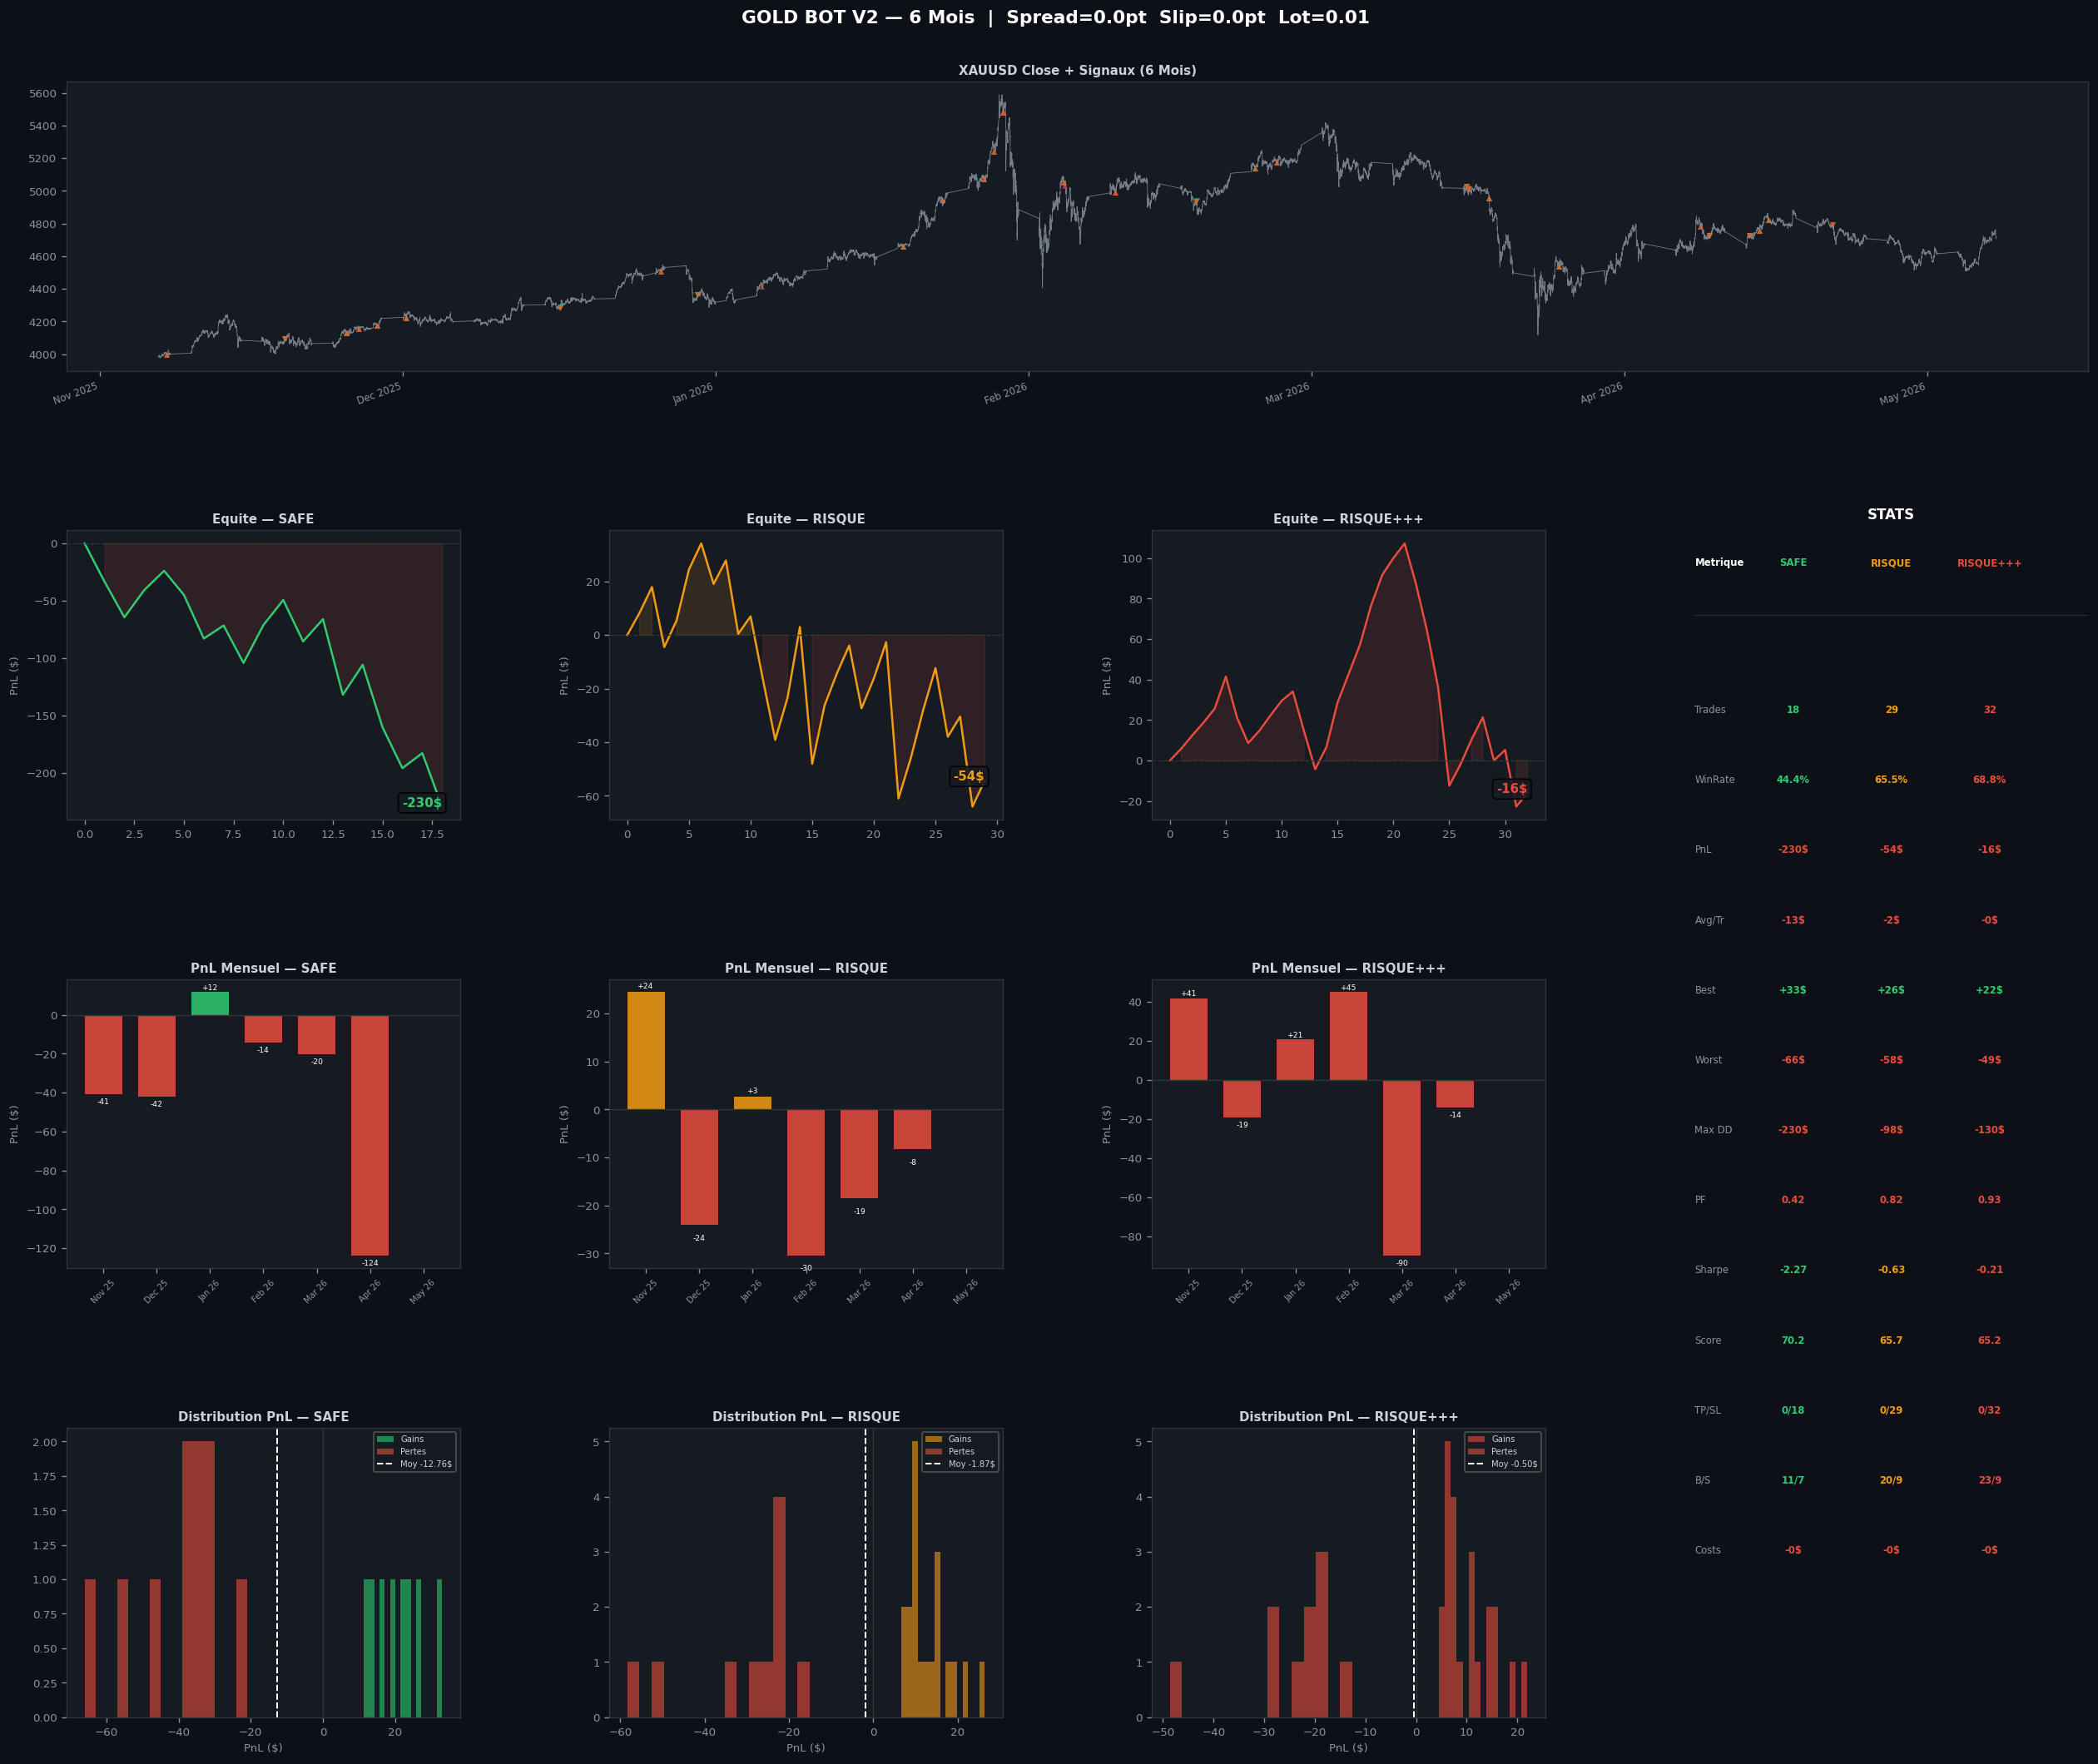

Dashboard sauvegarde: dashboard_6_Mois.png

  Dashboard: 1 An


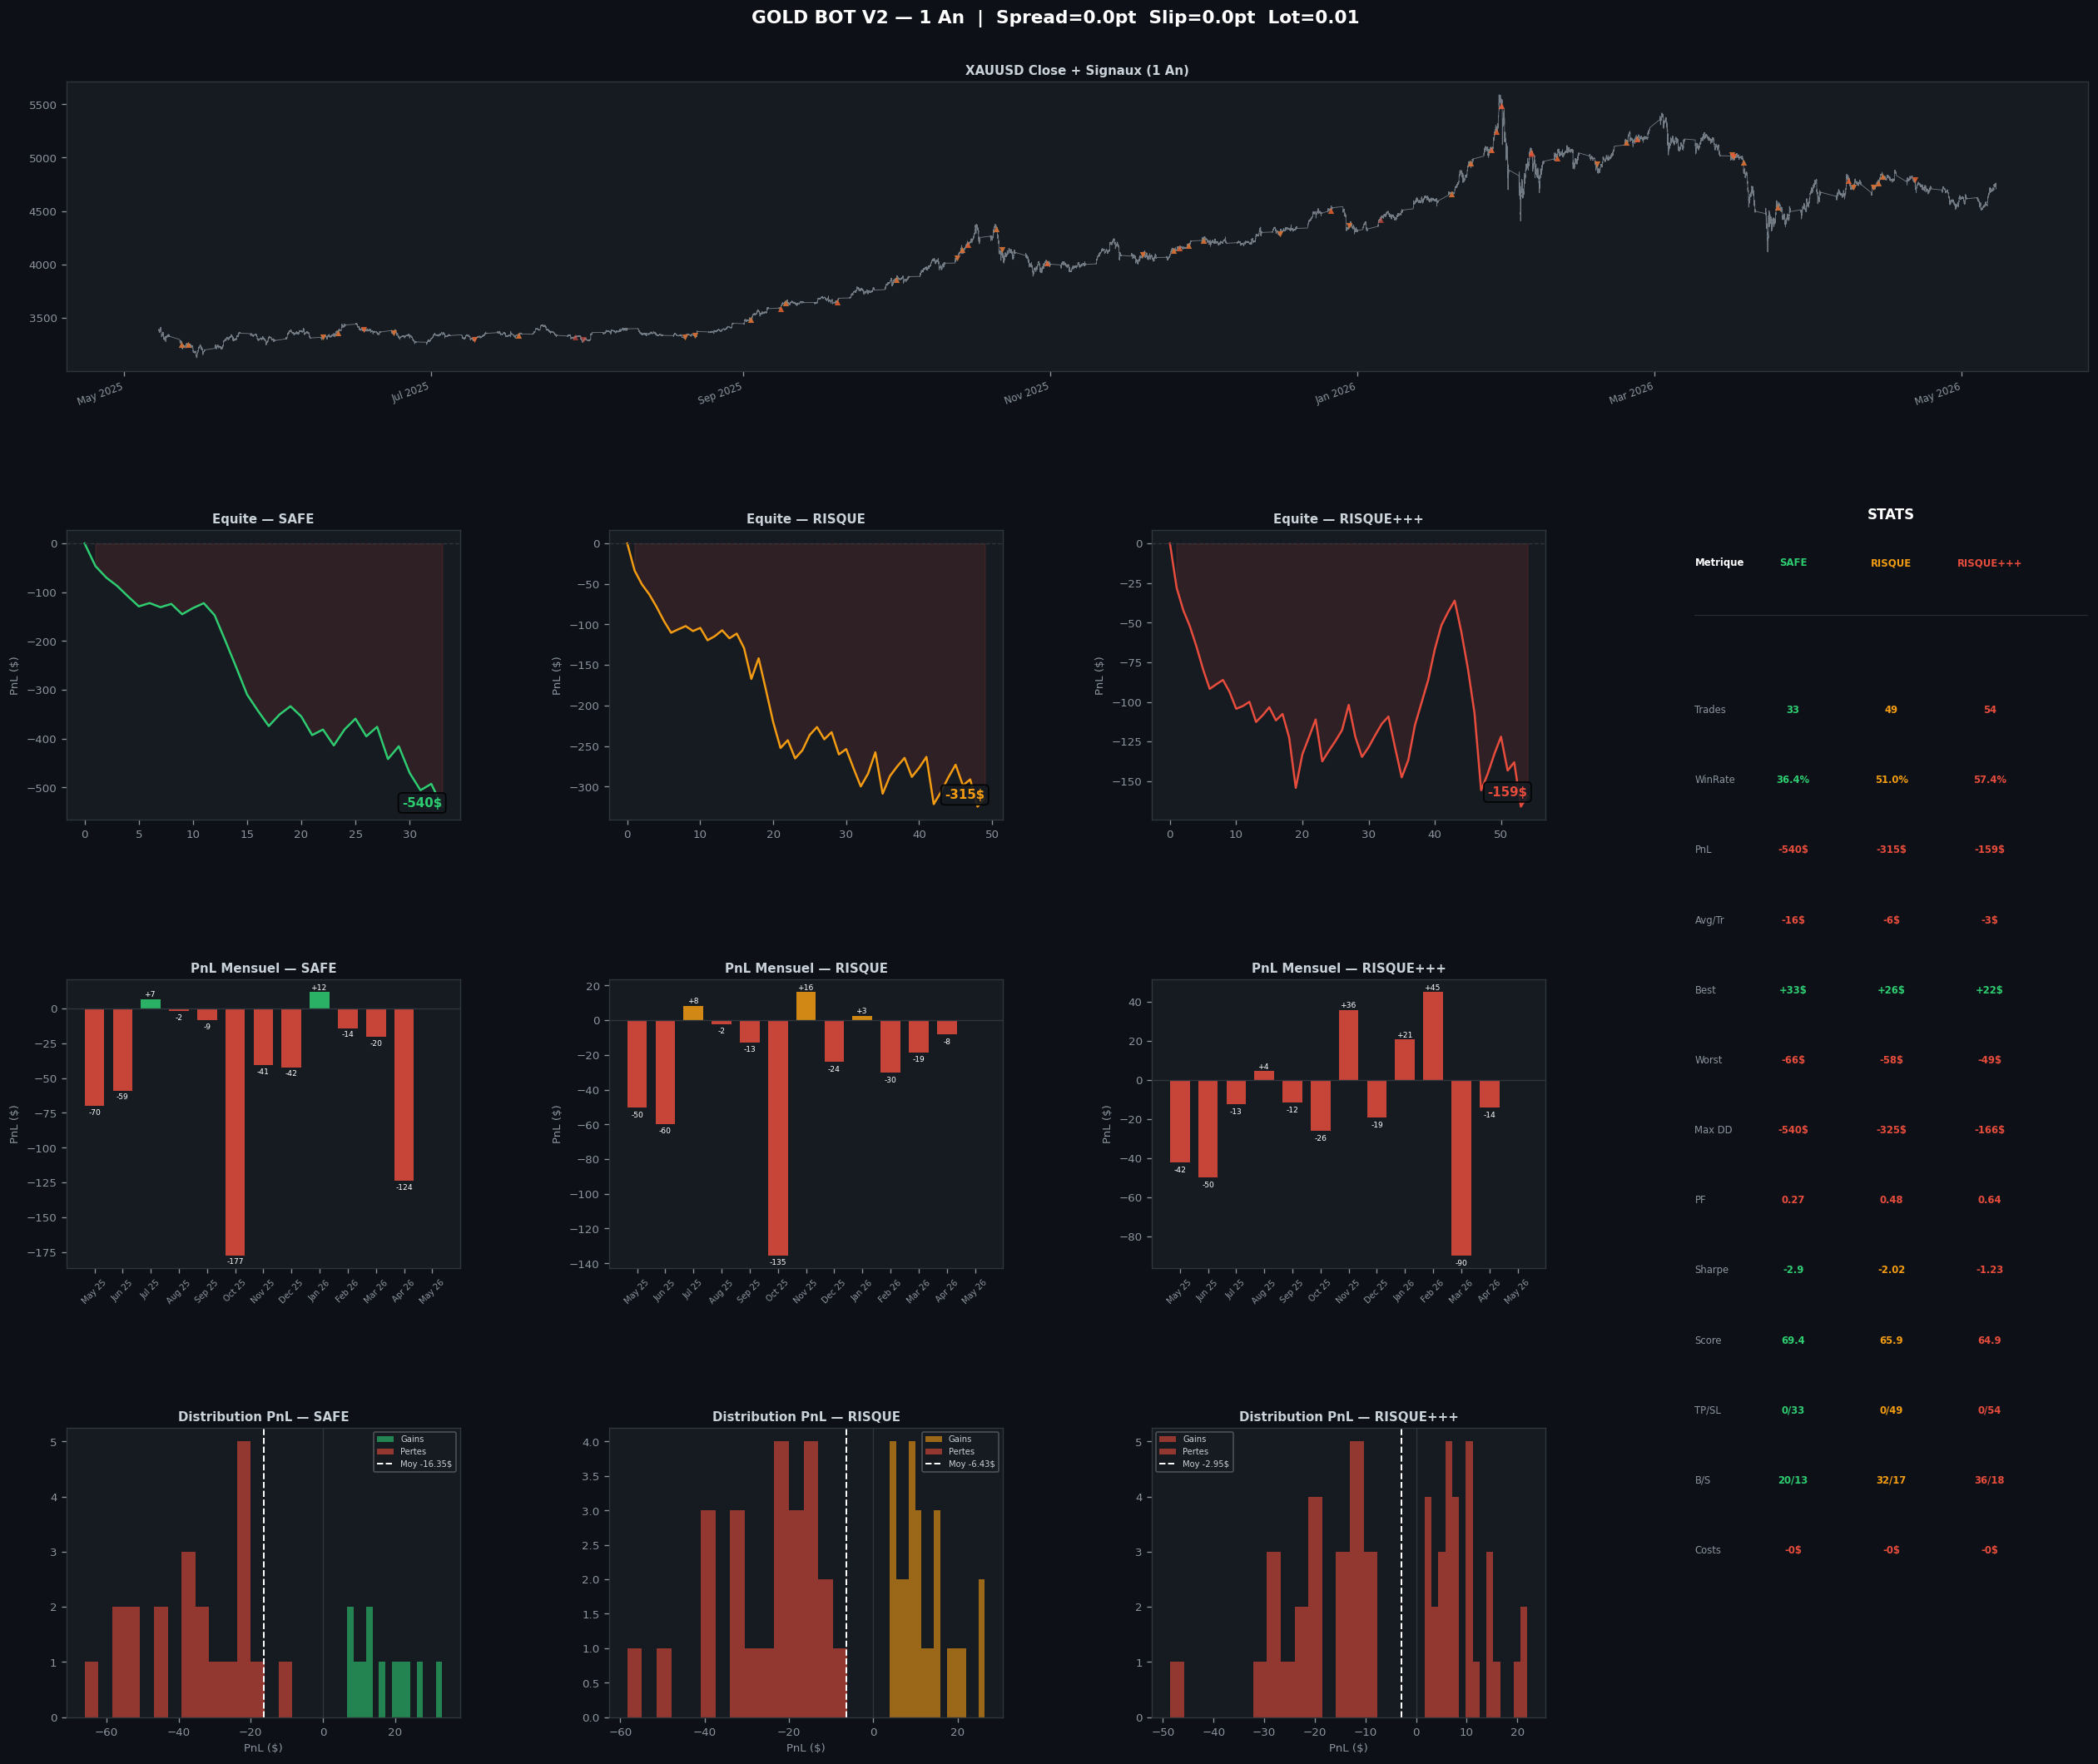

Dashboard sauvegarde: dashboard_1_An.png

  Dashboard: 2 Ans


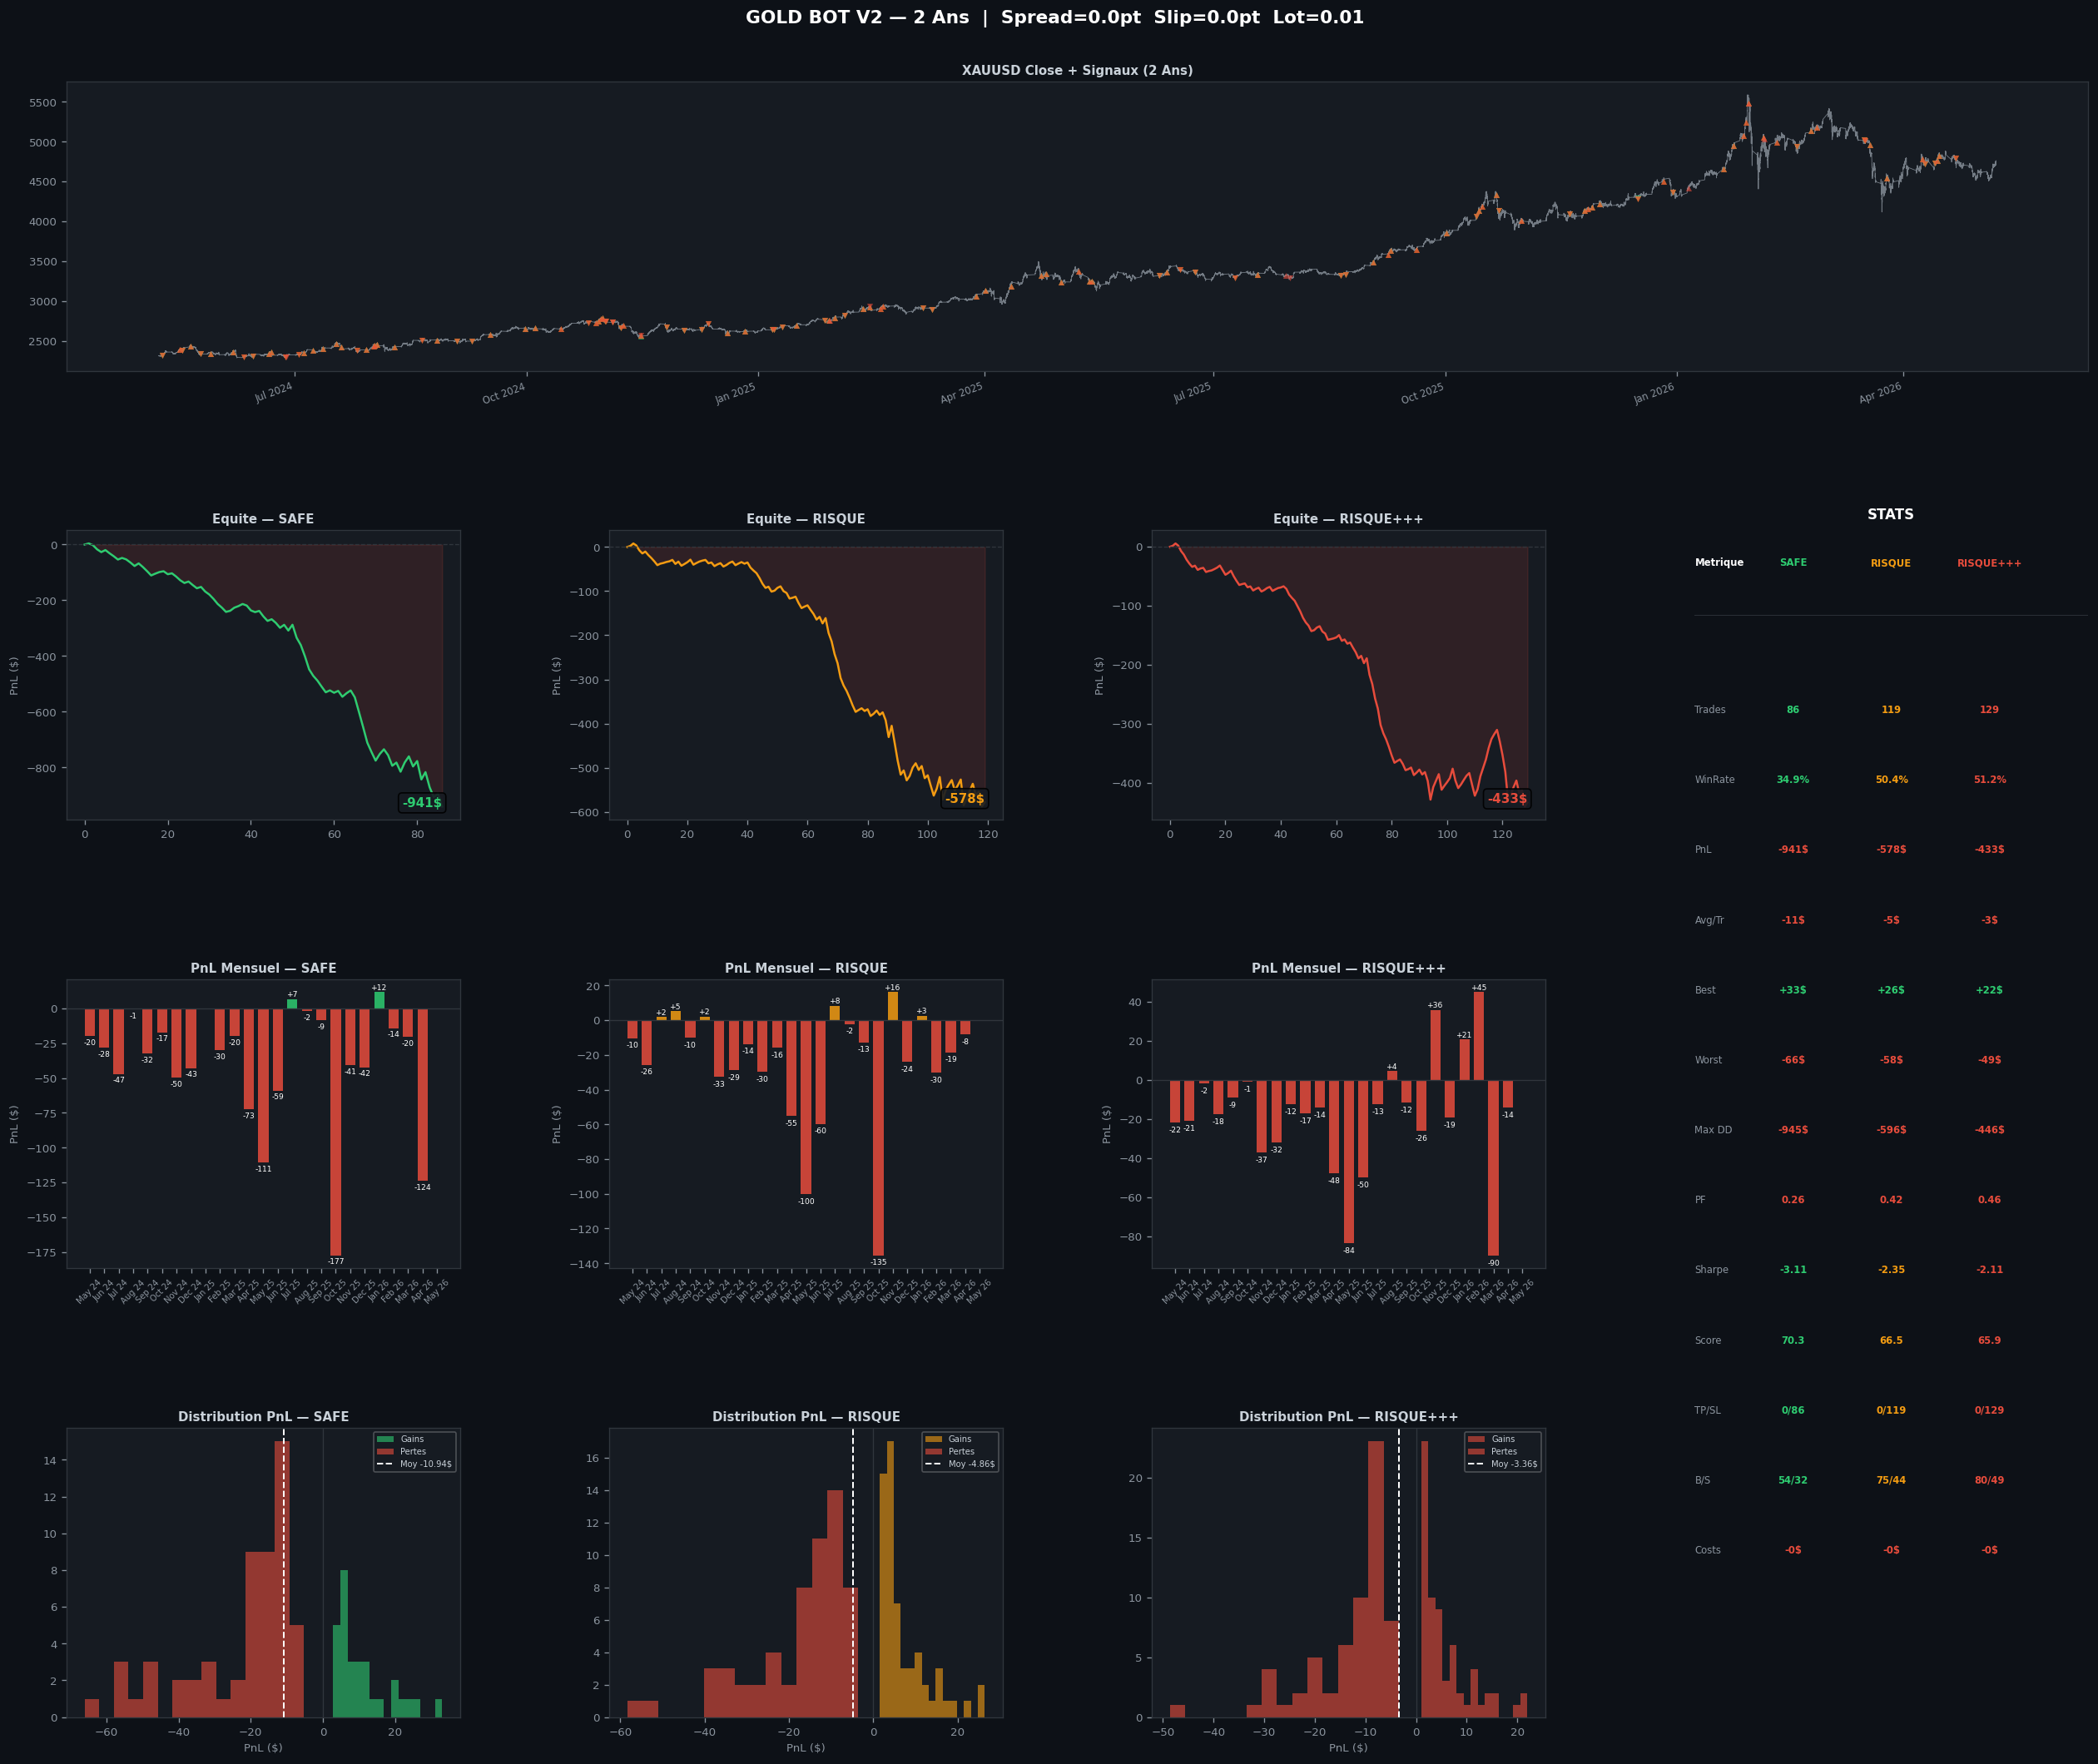

Dashboard sauvegarde: dashboard_2_Ans.png

  Dashboard: 3 Ans


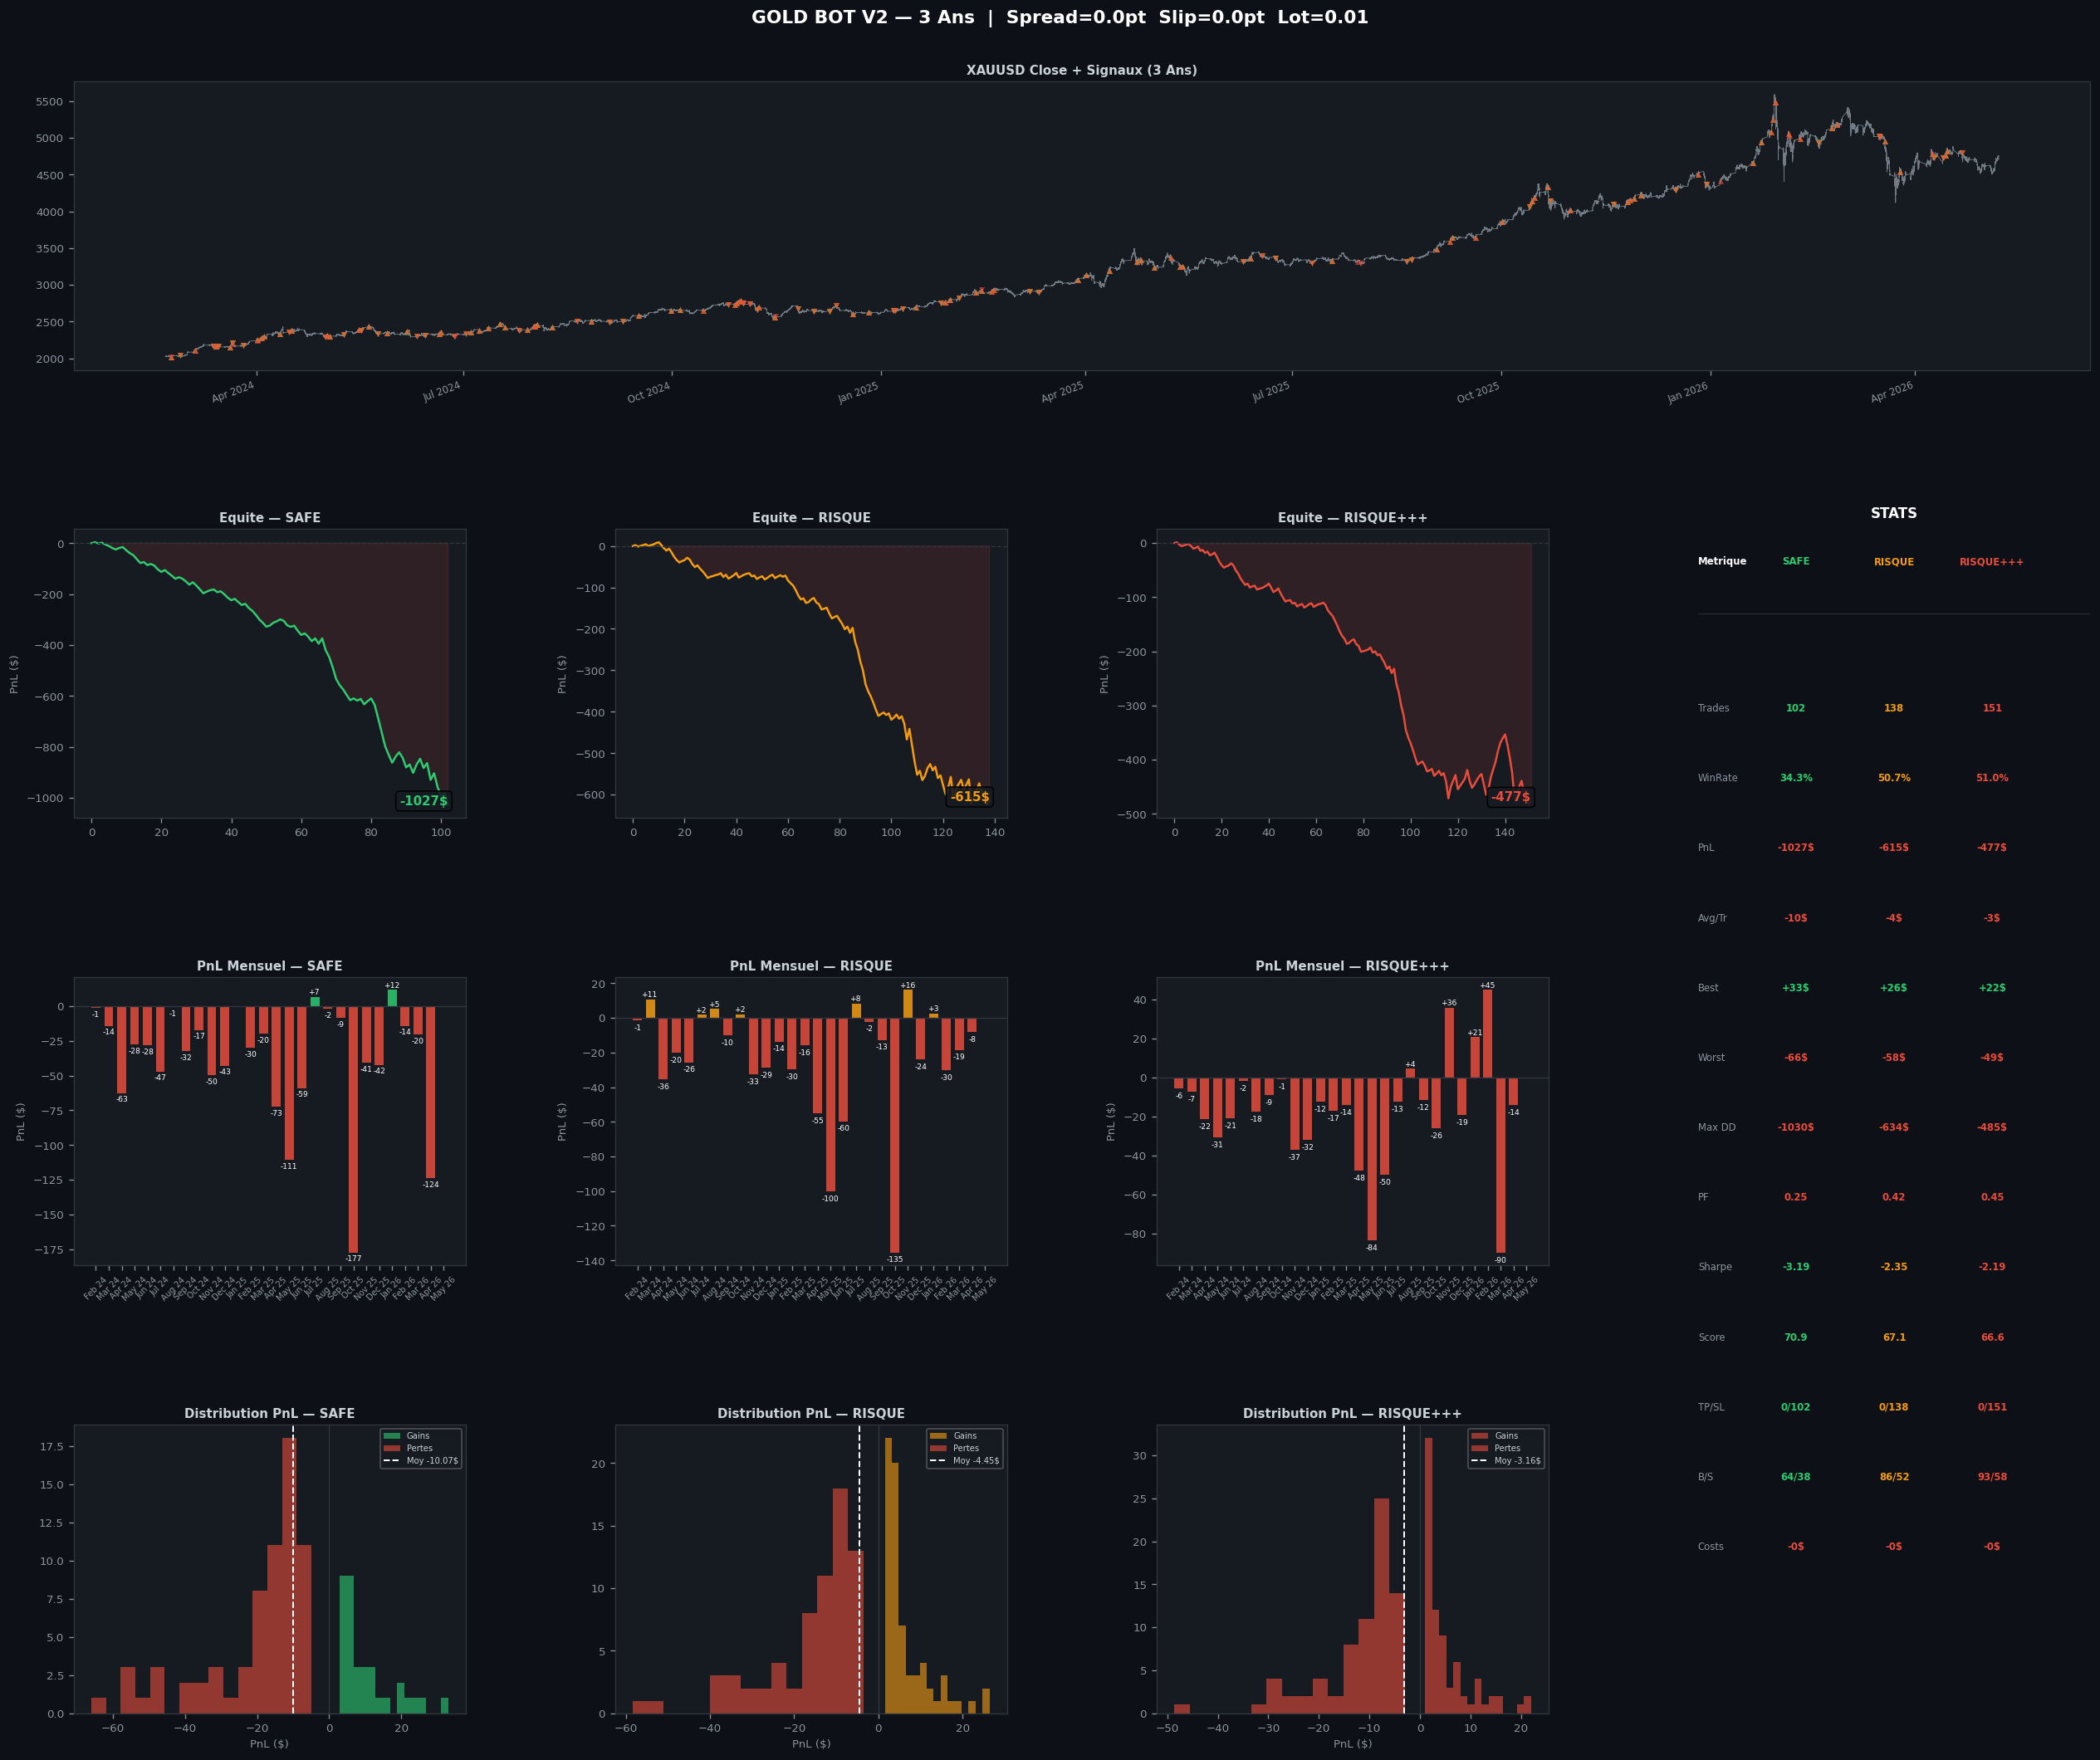

Dashboard sauvegarde: dashboard_3_Ans.png


In [8]:
BG='#0d1117'; BG2='#161b22'; BD='#30363d'; TXT='#c9d1d9'; MT='#8b949e'

def sax(ax,title=''):
    ax.set_facecolor(BG2)
    for s in ax.spines.values(): s.set_color(BD)
    ax.tick_params(colors=MT,labelsize=8)
    ax.xaxis.label.set_color(MT); ax.yaxis.label.set_color(MT)
    if title: ax.set_title(title,color=TXT,fontsize=9,fontweight='bold',pad=5)

def plot_dashboard(ds_name,df_price,mres):
    ml=list(mres.keys()); n=len(ml)
    colors=[MODES_CONFIG[m]['color'] for m in ml]
    labels=[MODES_CONFIG[m]['label'] for m in ml]
    fig=plt.figure(figsize=(22,18),facecolor=BG)
    fig.suptitle(f'GOLD BOT V2 — {ds_name}  |  Spread={SPREAD}pt  Slip={SLIPPAGE}pt  Lot={LOT_SIZE}',
                 fontsize=13,fontweight='bold',color='white',y=0.99)
    gs=gridspec.GridSpec(4,n+1,figure=fig,hspace=0.55,wspace=0.38,
                         left=0.05,right=0.97,top=0.95,bottom=0.04)

    ax_p=fig.add_subplot(gs[0,:])
    sax(ax_p,f'XAUUSD Close + Signaux ({ds_name})')
    x=pd.to_datetime(df_price['time']) if 'time' in df_price.columns else range(len(df_price))
    ax_p.plot(x,df_price['Close'],color=MT,lw=0.5,alpha=0.8)
    for m,col in zip(ml,colors):
        td=mres[m]['trades_df']
        if td.empty: continue
        bu=td[td['direction']=='BUY']; se=td[td['direction']=='SELL']
        bx=pd.to_datetime(bu['time']); sx=pd.to_datetime(se['time'])
        ax_p.scatter(bx,bu['entry_raw'],marker='^',s=18,color=col,alpha=0.6,zorder=3,linewidths=0)
        ax_p.scatter(sx,se['entry_raw'],marker='v',s=18,color=col,alpha=0.6,zorder=3,linewidths=0)
    ax_p.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(ax_p.xaxis.get_majorticklabels(),rotation=20,ha='right',fontsize=7)

    for col,(mode,color,label) in enumerate(zip(ml,colors,labels)):
        res=mres[mode]; ax=fig.add_subplot(gs[1,col])
        sax(ax,f'Equite — {label}')
        eq=res['equity']; xe=range(len(eq))
        ax.plot(xe,eq,color=color,lw=1.5)
        ax.axhline(0,color=BD,lw=0.8,ls='--')
        ax.fill_between(xe,eq,0,where=[e>0 for e in eq],alpha=0.12,color=color)
        ax.fill_between(xe,eq,0,where=[e<0 for e in eq],alpha=0.12,color='#e74c3c')
        ax.set_ylabel('PnL ($)',fontsize=8)
        f=eq[-1]
        ax.annotate(f'{f:+.0f}$',xy=(len(eq)-1,f),color=color,fontsize=9,
                    fontweight='bold',ha='right',
                    bbox=dict(boxstyle='round,pad=0.3',facecolor=BG2,alpha=0.9))

    for col,(mode,color,label) in enumerate(zip(ml,colors,labels)):
        res=mres[mode]; ax=fig.add_subplot(gs[2,col])
        sax(ax,f'PnL Mensuel — {label}')
        if not res['daily_pnl']: continue
        d=pd.Series(res['daily_pnl'])
        d.index=pd.to_datetime(list(res['daily_pnl'].keys()))
        mo=d.resample('ME').sum()
        bc=[color if v>=0 else '#e74c3c' for v in mo.values]
        bars=ax.bar(range(len(mo)),mo.values,color=bc,width=0.7,alpha=0.85)
        ax.axhline(0,color=BD,lw=0.8)
        ax.set_xticks(range(len(mo)))
        ax.set_xticklabels([d.strftime('%b %y') for d in mo.index],rotation=45,fontsize=6)
        ax.set_ylabel('PnL ($)',fontsize=8)
        for bar,v in zip(bars,mo.values):
            if abs(v)>0.5:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+(0.5 if v>=0 else -2),
                        f'{v:+.0f}',ha='center',va='bottom' if v>=0 else 'top',
                        fontsize=5.5,color='white')

    for col,(mode,color,label) in enumerate(zip(ml,colors,labels)):
        res=mres[mode]; ax=fig.add_subplot(gs[3,col])
        sax(ax,f'Distribution PnL — {label}')
        if res['trades_df'].empty: continue
        pnls=res['trades_df']['total_pnl']
        ax.hist(pnls[pnls>0],bins=15,color=color,alpha=0.6,label='Gains')
        ax.hist(pnls[pnls<0],bins=15,color='#e74c3c',alpha=0.6,label='Pertes')
        ax.axvline(pnls.mean(),color='white',lw=1.2,ls='--',label=f'Moy {pnls.mean():+.2f}$')
        ax.axvline(0,color=BD,lw=0.8)
        ax.legend(fontsize=6,framealpha=0.3,facecolor=BG2,labelcolor=TXT)
        ax.set_xlabel('PnL ($)',fontsize=8)

    ax_t=fig.add_subplot(gs[1:,-1])
    ax_t.set_facecolor(BG2); ax_t.axis('off')
    ax_t.set_title('STATS',color='white',fontsize=10,fontweight='bold',pad=8)
    metrics=[('Trades',  lambda r: str(r['n_sequences'])),
             ('WinRate', lambda r: f"{r['winrate']}%"),
             ('PnL',     lambda r: f"{r['total_pnl']:+.0f}$"),
             ('Avg/Tr',  lambda r: f"{r['avg_pnl']:+.0f}$"),
             ('Best',    lambda r: f"{r['best']:+.0f}$"),
             ('Worst',   lambda r: f"{r['worst']:+.0f}$"),
             ('Max DD',  lambda r: f"{r['max_dd']:.0f}$"),
             ('PF',      lambda r: f"{r['profit_factor']:.2f}" if r['profit_factor']!=float('inf') else 'inf'),
             ('Sharpe',  lambda r: str(r['sharpe'])),
             ('Score',   lambda r: f"{r['avg_score']}"),
             ('TP/SL',   lambda r: f"{r['n_tp']}/{r['n_sl']}"),
             ('B/S',     lambda r: f"{r['n_buy']}/{r['n_sell']}"),
             ('Costs',   lambda r: f"-{r['total_transaction_costs']:.0f}$")]
    hdrs=['Metrique']+[MODES_CONFIG[m]['label'] for m in ml]
    rc=[MODES_CONFIG[m]['color'] for m in ml]
    y=0.97; dy=0.059
    for j,h in enumerate(hdrs):
        xp=j/len(hdrs); c='white' if j==0 else rc[j-1]
        ax_t.text(xp,y,h,color=c,fontsize=7,fontweight='bold',transform=ax_t.transAxes,
                  ha='left' if j==0 else 'center')
    y-=dy*0.7
    ax_t.axhline(y,color=BD,lw=0.5); y-=dy*0.4
    for lbl,fn in metrics:
        y-=dy
        ax_t.text(0,y,lbl,color=MT,fontsize=7,transform=ax_t.transAxes)
        for j,mode in enumerate(ml):
            val=fn(mres[mode]); xp=(j+1)/len(hdrs); c=rc[j]
            if '$' in val:
                try:
                    vv=float(val.replace('$','').replace('+','').replace('-',''))
                    if 'Costs' in lbl: c='#e74c3c'
                    elif 'DD' in lbl: c='#e74c3c' if vv>20 else '#f39c12'
                    else: c='#2ecc71' if float(val.replace('$','').replace('+',''))>0 else '#e74c3c'
                except: pass
            elif lbl=='PF':
                try:
                    vv=float(val)
                    c='#2ecc71' if vv>=1.8 else ('#f39c12' if vv>=1.4 else '#e74c3c')
                except: pass
            ax_t.text(xp,y,val,color=c,fontsize=7,transform=ax_t.transAxes,
                      ha='center',fontweight='bold')

    fn_out=f'dashboard_{ds_name.replace(" ","_")}.png'
    plt.savefig(fn_out,dpi=130,bbox_inches='tight',facecolor=BG)
    plt.show()
    print(f'Dashboard sauvegarde: {fn_out}')

for ds_name,df in LOADED.items():
    if ds_name in ALL_RESULTS:
        print(f'\n{"="*55}\n  Dashboard: {ds_name}\n{"="*55}')
        plot_dashboard(ds_name,df,ALL_RESULTS[ds_name])


## 🏆 Comparaison Multi-Dataset


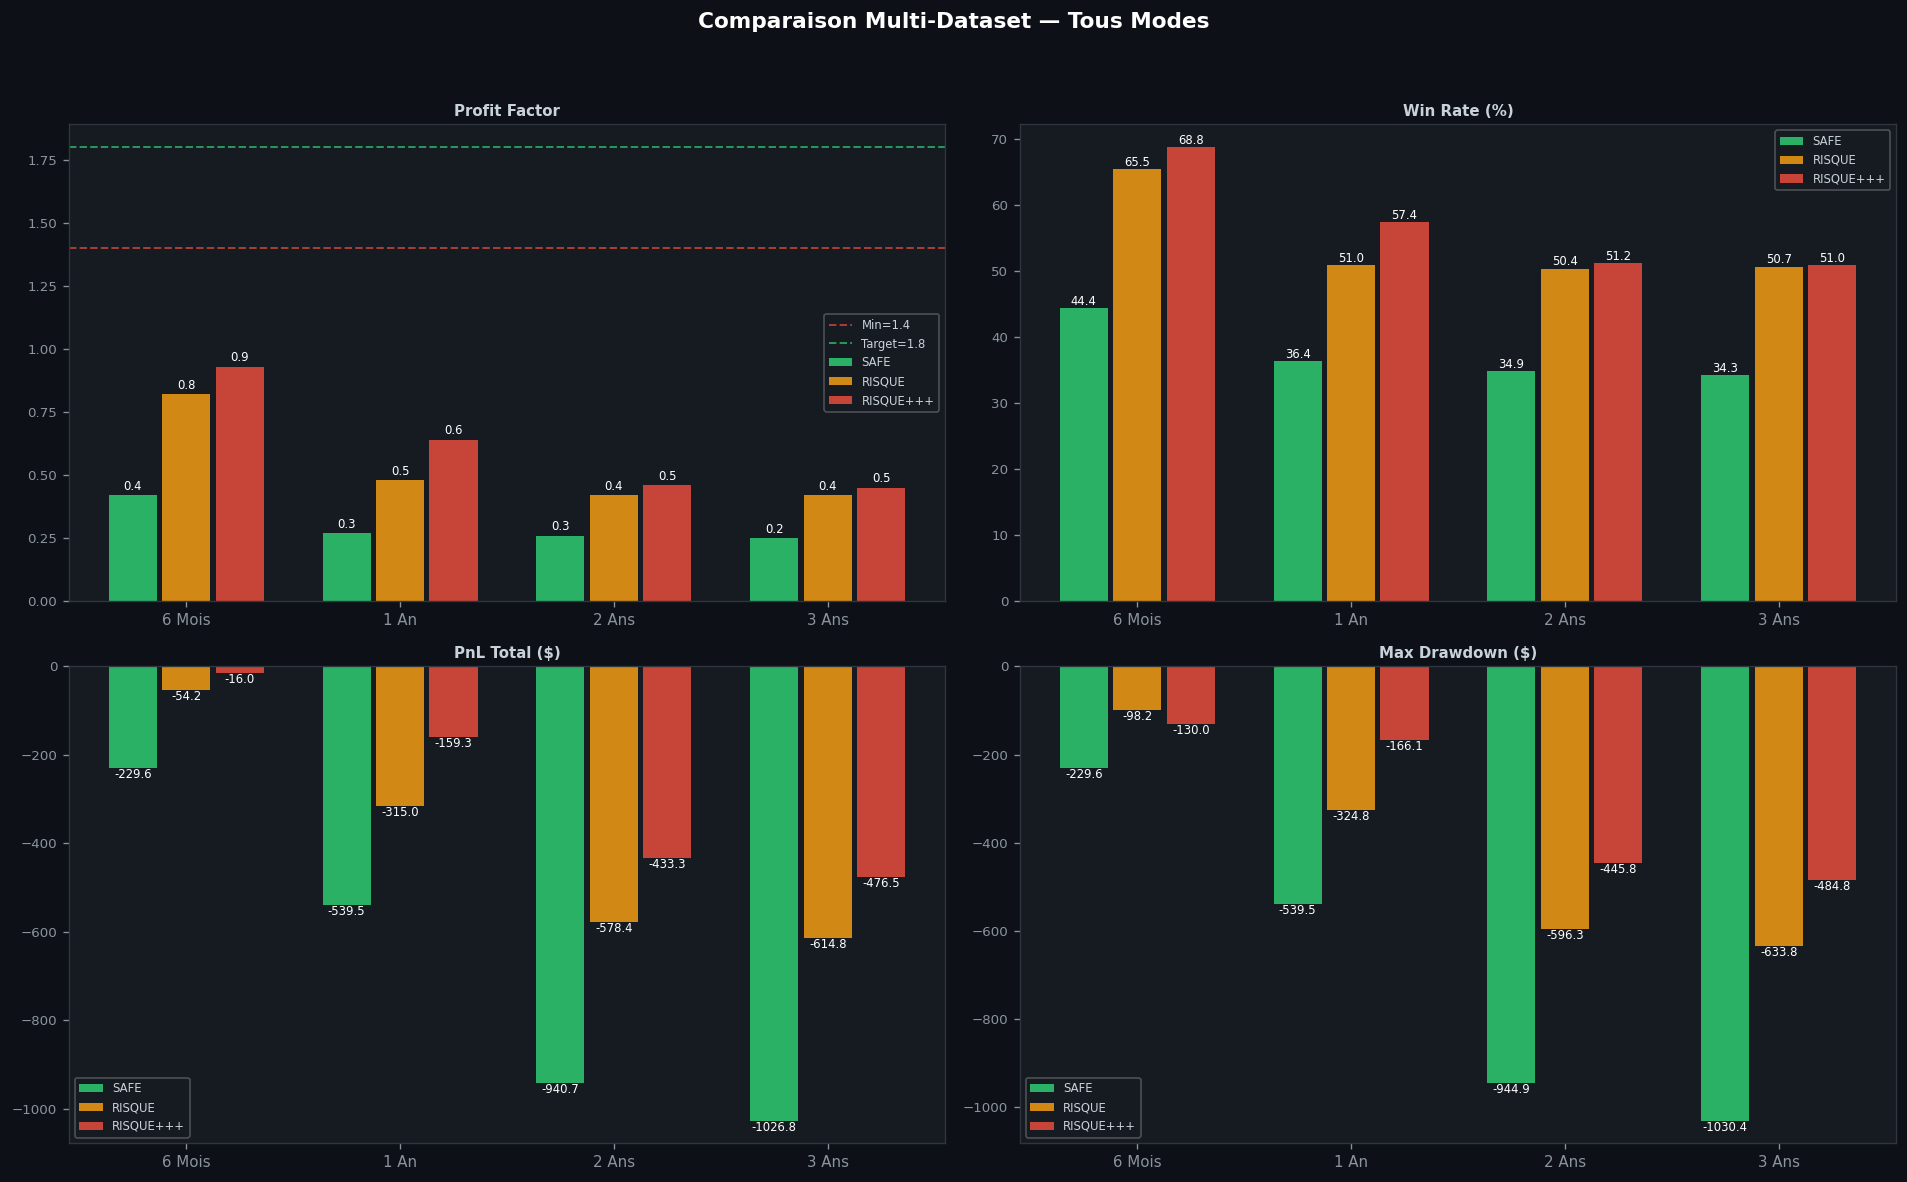

Comparaison sauvegardee: comparison_multi_dataset.png


In [9]:
if len(ALL_RESULTS)>1:
    fig,axes=plt.subplots(2,2,figsize=(16,10),facecolor=BG)
    fig.suptitle('Comparaison Multi-Dataset — Tous Modes',color='white',fontsize=13,fontweight='bold')
    metrics_chart=[
        ('profit_factor','Profit Factor',axes[0,0],[1.4,1.8]),
        ('winrate','Win Rate (%)',axes[0,1],None),
        ('total_pnl','PnL Total ($)',axes[1,0],None),
        ('max_dd','Max Drawdown ($)',axes[1,1],None),
    ]
    ds_names=list(ALL_RESULTS.keys())
    xn=np.arange(len(ds_names)); w=0.25
    for (metric,title,ax,thr) in metrics_chart:
        sax(ax,title)
        for i,mode in enumerate(MODES):
            vals=[ALL_RESULTS[ds][mode][metric] if ALL_RESULTS[ds][mode][metric]!=float('inf') else 10
                  for ds in ds_names]
            bars=ax.bar(xn+i*w-w,vals,w*0.9,label=MODES_CONFIG[mode]['label'],
                        color=MODES_CONFIG[mode]['color'],alpha=0.85)
            for bar,v in zip(bars,vals):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+(0.01 if v>=0 else -0.05),
                        f'{v:.1f}',ha='center',va='bottom' if v>=0 else 'top',
                        fontsize=7,color='white')
        if thr:
            for t,lbl,col in zip(thr,['Min','Target'],['#e74c3c','#2ecc71']):
                ax.axhline(t,color=col,lw=1.2,ls='--',alpha=0.7,label=f'{lbl}={t}')
        ax.axhline(0,color=BD,lw=0.6)
        ax.set_xticks(xn); ax.set_xticklabels(ds_names,fontsize=9)
        ax.legend(fontsize=7,framealpha=0.3,facecolor=BG2,labelcolor=TXT)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.savefig('comparison_multi_dataset.png',dpi=130,bbox_inches='tight',facecolor=BG)
    plt.show()
    print('Comparaison sauvegardee: comparison_multi_dataset.png')
else:
    print('Il faut au moins 2 datasets charges pour la comparaison.')


## 💾 Export Excel — Tous les Trades


In [10]:
def export_excel(filename='backtest_complet.xlsx'):
    try:
        import openpyxl
        from openpyxl.styles import PatternFill,Font,Alignment
        wb=openpyxl.Workbook(); wb.remove(wb.active)

        ws0=wb.create_sheet('RESUME GLOBAL',0)
        hdr=['Dataset','Mode','Trades','WinRate','PnL Total','PnL Moyen',
             'Meilleur','Pire','Max DD','PF','Sharpe','TP','SL','Couts']
        ws0.append(hdr)
        for cell in ws0[1]:
            cell.fill=PatternFill('solid',fgColor='1F4E79')
            cell.font=Font(color='FFFFFF',bold=True)
            cell.alignment=Alignment(horizontal='center')
        for ds,modes in ALL_RESULTS.items():
            for mode,res in modes.items():
                pf=res['profit_factor']
                ws0.append([ds,MODES_CONFIG[mode]['label'],res['n_sequences'],
                            f"{res['winrate']}%",f"{res['total_pnl']:+.2f}$",
                            f"{res['avg_pnl']:+.2f}$",f"{res['best']:+.2f}$",
                            f"{res['worst']:+.2f}$",f"{res['max_dd']:.2f}$",
                            f"{pf:.2f}" if pf!=float('inf') else 'inf',
                            res['sharpe'],res['n_tp'],res['n_sl'],
                            f"-{res['total_transaction_costs']:.2f}$"])

        cols=['time','direction','entry_raw','entry_adj','sl','tp1','tp2','tp3',
              'risk_pts','score','threshold','transaction_cost',
              't1_result','t1_pnl','t2_result','t2_pnl','t3_result','t3_pnl',
              'total_pnl','result','reasons']
        for ds,modes in ALL_RESULTS.items():
            for mode,res in modes.items():
                sht=f"{ds[:7]}_{MODES_CONFIG[mode]['label'][:6]}"
                ws=wb.create_sheet(sht[:31])
                ws.append(cols)
                for cell in ws[1]:
                    cell.fill=PatternFill('solid',fgColor='1F4E79')
                    cell.font=Font(color='FFFFFF',bold=True)
                    cell.alignment=Alignment(horizontal='center')
                if res['trades_df'].empty: ws.append(['Aucun trade']); continue
                df_t=res['trades_df']
                ec=[c for c in cols if c in df_t.columns]
                for _,row in df_t[ec].iterrows():
                    ws.append(list(row))
                    last=ws.max_row
                    pnl=row.get('total_pnl',0)
                    if 'total_pnl' in ec:
                        idx=ec.index('total_pnl')+1
                        ws.cell(last,idx).fill=PatternFill('solid',fgColor='1a5c2e' if pnl>0 else '5c1a1a')
                        ws.cell(last,idx).font=Font(color='FFFFFF',bold=True)

        wb.save(filename)
        print(f'Export OK: {filename}')
        print(f'Feuilles: RESUME GLOBAL + {sum(len(v) for v in ALL_RESULTS.values())} onglets trades')
    except ImportError:
        print('openpyxl manquant — pip install openpyxl')

export_excel()


Export OK: backtest_complet.xlsx
Feuilles: RESUME GLOBAL + 12 onglets trades


## 🎯 Recommandations Finales


In [11]:
print('\n' + '='*65)
print('  ANALYSE & RECOMMANDATIONS')
print('='*65)

for ds_name,modes in ALL_RESULTS.items():
    print(f'\nDataset: {ds_name}')
    bpf=max(modes,key=lambda m: modes[m]['profit_factor'] if modes[m]['profit_factor']!=float('inf') else 999)
    bsh=max(modes,key=lambda m: modes[m]['sharpe'])
    for mode,res in modes.items():
        pf=res['profit_factor']
        pfs=f'{pf:.2f}' if pf!=float('inf') else 'inf'
        pff='[OK]' if pf>=1.8 else ('[WARN]' if pf>=1.4 else '[FAIL]')
        ddf='[OK]' if abs(res['max_dd'])<50 else ('[WARN]' if abs(res['max_dd'])<100 else '[FAIL]')
        m=MODES_CONFIG[mode]
        print(f'   {m["label"]:12s} PF={pfs} {pff}  DD={res["max_dd"]:.0f}$ {ddf}  '
              f'Sharpe={res["sharpe"]:5.2f}  WR={res["winrate"]}%')
    print(f'   -> Meilleur PF:     {MODES_CONFIG[bpf]["label"]}')
    print(f'   -> Meilleur Sharpe: {MODES_CONFIG[bsh]["label"]}')

print('\n' + '-'*65)
print('  Criteres pour passer en LIVE :')
print('   Profit Factor > 1.8  (minimum absolu : 1.4)')
print('   Max Drawdown  < 15% du capital')
print('   Sharpe        > 1.0')
print('   Win Rate      > 45%')
print(f'  Config: Spread={SPREAD}pt | Slippage={SLIPPAGE}pt | Lot={LOT_SIZE}')
print('='*65)



  ANALYSE & RECOMMANDATIONS

Dataset: 6 Mois
   SAFE         PF=0.42 [FAIL]  DD=-230$ [FAIL]  Sharpe=-2.27  WR=44.4%
   RISQUE       PF=0.82 [FAIL]  DD=-98$ [WARN]  Sharpe=-0.63  WR=65.5%
   RISQUE+++    PF=0.93 [FAIL]  DD=-130$ [FAIL]  Sharpe=-0.21  WR=68.8%
   -> Meilleur PF:     RISQUE+++
   -> Meilleur Sharpe: RISQUE+++

Dataset: 1 An
   SAFE         PF=0.27 [FAIL]  DD=-540$ [FAIL]  Sharpe=-2.90  WR=36.4%
   RISQUE       PF=0.48 [FAIL]  DD=-325$ [FAIL]  Sharpe=-2.02  WR=51.0%
   RISQUE+++    PF=0.64 [FAIL]  DD=-166$ [FAIL]  Sharpe=-1.23  WR=57.4%
   -> Meilleur PF:     RISQUE+++
   -> Meilleur Sharpe: RISQUE+++

Dataset: 2 Ans
   SAFE         PF=0.26 [FAIL]  DD=-945$ [FAIL]  Sharpe=-3.11  WR=34.9%
   RISQUE       PF=0.42 [FAIL]  DD=-596$ [FAIL]  Sharpe=-2.35  WR=50.4%
   RISQUE+++    PF=0.46 [FAIL]  DD=-446$ [FAIL]  Sharpe=-2.11  WR=51.2%
   -> Meilleur PF:     RISQUE+++
   -> Meilleur Sharpe: RISQUE+++

Dataset: 3 Ans
   SAFE         PF=0.25 [FAIL]  DD=-1030$ [FAIL]  Sharpe=-3.19